In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from brian2 import *

# Section 1: The Leaky Integrate-and-Fire (LIF) model

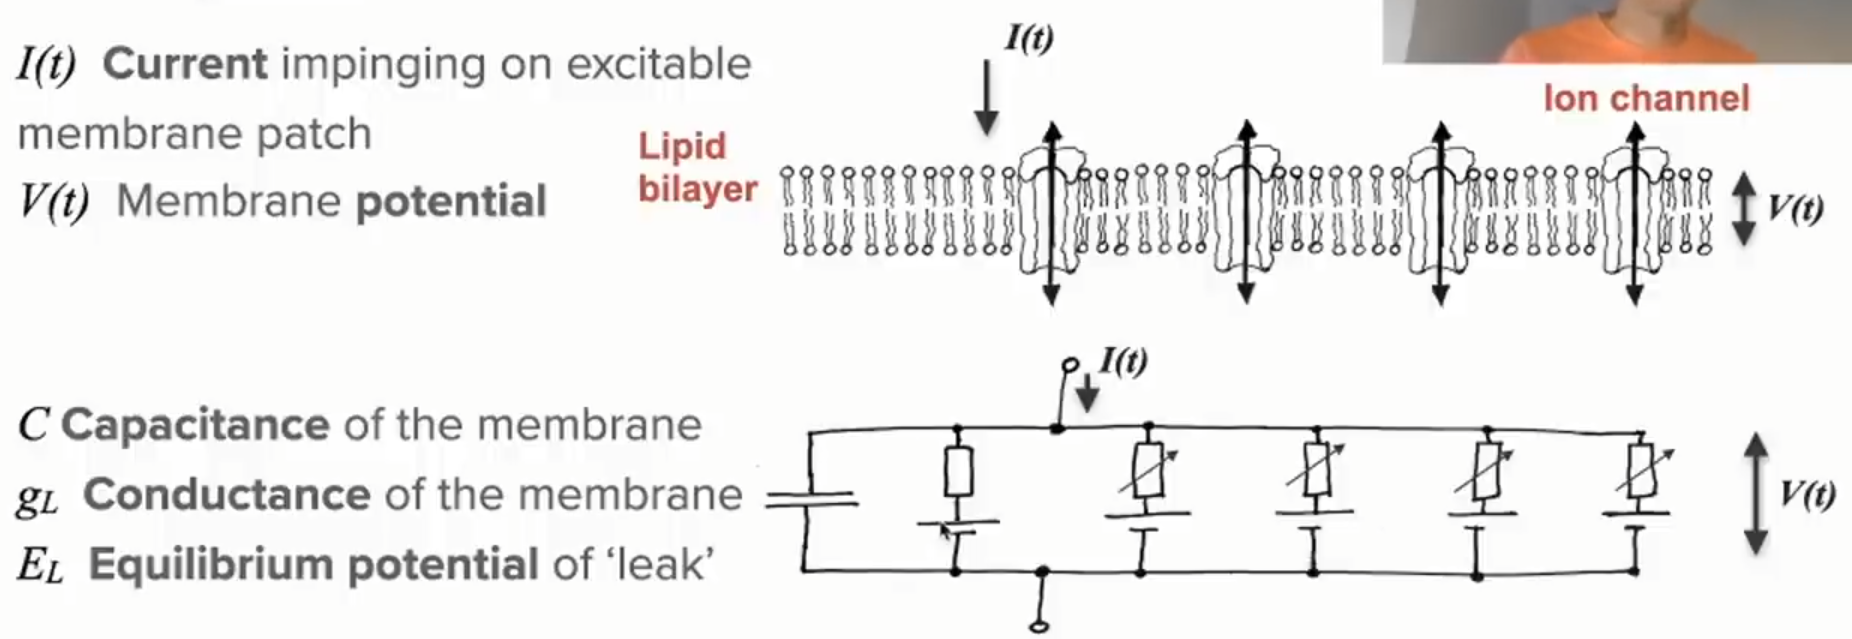

**重點整理：**
- **LIF 模型** (Leaky Integrate-and-Fire) 是用來描述神經元膜電位演化的基礎模型。
- **洩漏 (Leaky)**：當沒有輸入電流時，膜電位會透過電導 $g_L$ 緩慢回歸到靜息電位 $E_L$。
- **積分 (Integrate)**：累積外部注入電流 $I_{in}$ 造成的電位變化。
- **發射 (Fire)**：一旦電位到達閾值 $V_{th}$，模型會「記錄」一次脈衝 (Spike)，並將電位重置到 $V_{reset}$。
- **方程式 0 (H-H) 最貼近生物意義**:
    - $E_?$ 表示目標必須是多少電壓
    - $g_?$ 表示電壓變化的速度具體要多快
        - $C_m \frac{dV}{dt} = -g_L(V - E_L) - g_{Na}(V - E_{Na}) - g_{K}(V - E_{K}) g_{Ca}(V - E_{Ca}) + I_{in}$
        - 換成電流表示
         $C_m \frac{dV}{dt} = -g_L(V - E_L) - I_{Na} - I_{K} - I_{Ca} + I_{in}$
    - 假設不考慮其他離子通道，就會變成 **方程式 1**
- **方程式 1 (LIF)**: $C_m \frac{dV}{dt} = -g_L(V - E_L) + I_{in}$
    - $\tau = RC$，$R = \frac{1}{g_L}$，因此同除 $g_L$
- **方程式 2 (LIF)**： $\tau_m \frac{dV}{dt} = -(V - E_L) + \frac{I_{in}}{g_L}$

這些方程式表達了膜電位變化率，簡化成了兩個電流的組成(外部輸入，靜息電位)

解 ODE & 運作流程: 

* $V(t) = \left( E_L + \frac{I_{in}}{g_L} \right) + \left[ V(0) - \left( E_L + \frac{I_{in}}{g_L} \right) \right] e^{-\frac{t}{\tau_m}}$
* $V(t) > V_{th}$ 的話: $V(t) \to V(t + t_{ref}) = V_{reset}$
    * $t_{ref}$ 是模擬一段時間的不應期

但實際上不會直接用 ODE，會使用 Euler Method，可以想想看如果 $I_{in}$ 不在是常數會發生甚麼

* $V_{t+1} = V_t + \frac{\Delta t}{\tau_m} \left[ -(V_t - E_L) + \frac{I_{in}}{g_L} \right]$
* $V(t) > V_{th}$ 的話: $V(t) \to V(t + t_{ref}) = V_{reset}$

In [ ]:

@widgets.interact(
    tau_m_val=widgets.FloatSlider(value=10.0, min=1.0, max=50.0, step=1.0, description='tau_m (ms)'),
    I_amp_val=widgets.FloatSlider(value=250.0, min=0.0, max=500.0, step=10.0, description='I_inj (pA)'),
    V_th_val=widgets.FloatSlider(value=-55.0, min=-70.0, max=-40.0, step=1.0, description='V_th (mV)'),
    t_ref_val=widgets.FloatSlider(value=5.0, min=0.0, max=20.0, step=1.0, description='t_ref (ms)')
)

def plot_interactive_lif(tau_m_val=10.0, I_amp_val=250.0, V_th_val=-55.0, t_ref_val=5.0):
    # 重置 Brian2 的模擬上下文 (在互動環境中多次執行時必備)
    start_scope()
    
    # 1. 物理參數 (補回單位)
    tau_m = tau_m_val * ms 
    E_L = -75 * mV
    V_th = V_th_val * mV
    V_reset = -80 * mV 
    g_L = 10 * nS # 等效電導
    t_ref = t_ref_val * ms # 不應期
    
    # 2. 定義微分方程
    eqs = '''
    dv/dt = (-(v - E_L) + I/g_L) / tau_m : volt (unless refractory)
    I = I_func(t) : amp
    '''
    # unless refractory 意思就是非不應期

    # 3. 製作輸入電流 (100ms ~ 300ms 有電流)
    dt = 0.1 * ms
    T_total = 400 * ms
    I_values = np.zeros(int(T_total / dt)) * pA
    I_values[int(100*ms/dt):int(300*ms/dt)] = I_amp_val * pA
    I_func = TimedArray(I_values, dt=dt)
    
    # 4. 建立神經元
    G = NeuronGroup(1, 
                    model=eqs, 
                    threshold='v > V_th', 
                    reset='v = V_reset', 
                    refractory=t_ref, 
                    method='exact') # exact 快很多，但不是很通用
    
    G.v = E_L
    
    # 5. 監測與運行
    state_mon = StateMonitor(G, 'v', record=0)
    spike_mon = SpikeMonitor(G)
    
    run(T_total)
    
    # 6. 繪圖
    plt.figure(figsize=(10, 4))
    v_trace = state_mon.v[0]/mV
    times = state_mon.t/ms
    
    plt.plot(times, v_trace, label='Membrane Potential')
    
    # 視覺化 Spike
    for ts in spike_mon.t/ms:
        plt.vlines(ts, V_th_val, 0, colors='r', linestyles='-', alpha=0.6)
    
    plt.axhline(V_th_val, color='r', ls='--', label='Threshold')
    plt.title(f'LIF Neuron: tau_m={tau_m_val:.4f}ms, I={I_amp_val}pA')
    plt.ylabel('Voltage (mV)')
    plt.xlabel('Time (ms)')
    plt.ylim(-85, 5) 
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=10.0, description='tau_m (ms)', max=50.0, min=1.0, step=1.0), FloatSli…

# Section 2: Response of an LIF model to different types of input currents

*(TODO: 本章節探討不同輸入電流對 LIF 模型的影響。)*


## Section 2.1: Gaussian white noise (GWN) current

前面都是用常數電流作為輸入，但實際情況應該會有很多噪音才是

**重點整理：**
- **雜訊輸入**：可用 GWN 模擬突觸輸入的隨機波動。
- **參數**：均值 $\mu$ 與標準差 $\sigma$。
- 當 $\sigma$ 變大時，波動可能觸發原本 sub-threshold 的放電。


In [ ]:
start_scope()

@widgets.interact(
    tau_m_val=widgets.FloatSlider(value=10.0, min=1.0, max=50.0, step=1.0, description='tau_m (ms)'),
    I_amp_val=widgets.FloatSlider(value=250.0, min=0.0, max=500.0, step=10.0, description='I_inj (pA)'),
    sigma_val=widgets.FloatSlider(value=2.0, min=0.0, max=10.0, step=0.5, description='Noise σ (mV)'),
    V_th_val=widgets.FloatSlider(value=-55.0, min=-70.0, max=-40.0, step=1.0, description='V_th (mV)'),
    t_ref_val=widgets.FloatSlider(value=5.0, min=0.0, max=20.0, step=1.0, description='t_ref (ms)')
)
def plot_stochastic_lif_with_spikes(tau_m_val=10.0, I_amp_val=250.0, sigma_val=2.0, V_th_val=-55.0, t_ref_val=5.0):
    # 1. 隔離作用域
    start_scope()
    
    # 2. 物理參數 (補回單位與滑桿數值)
    tau_m = tau_m_val * ms 
    E_L = -75 * mV
    V_th = V_th_val * mV
    V_reset = -80 * mV 
    g_L = 10 * nS
    sigma = sigma_val * mV  # 噪音強度
    t_ref = t_ref_val * ms  # 不應期
    
    # 3. 定義微分方程 (帶隨機項與 unless refractory)
    eqs = '''
    dv/dt = (-(v - E_L) + I/g_L) / tau_m + sigma * xi * tau_m**-0.5 : volt (unless refractory)
    I = I_func(t) : amp
    '''

    # 4. 製作輸入電流 (100ms ~ 300ms 脈衝)
    dt = 0.1 * ms
    T_total = 400 * ms
    I_values = np.zeros(int(T_total / dt)) * pA
    I_values[int(100*ms/dt):int(300*ms/dt)] = I_amp_val * pA
    I_func = TimedArray(I_values, dt=dt)
    
    # 5. 建立神經元
    G = NeuronGroup(1, 
                    model=eqs, 
                    threshold='v > V_th', 
                    reset='v = V_reset', 
                    refractory=t_ref, 
                    method='euler') # 有隨機項須使用 euler
    
    G.v = E_L
    
    # 6. 監測器
    state_mon = StateMonitor(G, 'v', record=0)
    spike_mon = SpikeMonitor(G)
    
    run(T_total)
    
    # 7. 繪圖
    plt.figure(figsize=(12, 5))
    v_trace = state_mon.v[0]/mV
    times = state_mon.t/ms
    
    # 畫出膜電位軌跡
    plt.plot(times, v_trace, label='Membrane Potential', alpha=0.8)
    
    # 視覺化 Spike (拉紅色的垂直線)
    for ts in spike_mon.t/ms:
        plt.vlines(ts, V_th_val, 0, colors='r', linestyles='-', alpha=0.6)
    
    # 標註閾值線
    plt.axhline(V_th_val, color='r', ls='--', label='Threshold', alpha=0.5)
    
    plt.title(f'Stochastic LIF: τ={tau_m_val}ms, I={I_amp_val}pA, σ={sigma_val}mV, ref={t_ref_val}ms')
    plt.ylabel('Voltage (mV)')
    plt.xlabel('Time (ms)')
    plt.ylim(-85, 10) 
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()


interactive(children=(FloatSlider(value=10.0, description='tau_m (ms)', max=50.0, min=1.0, step=1.0), FloatSli…

# Section 3: Firing rate and spike time irregularity

**重點整理：**
- **F-I 曲線**：雜訊 $\sigma$ 會讓 F-I 曲線變得圓滑。
- **規律性指標 ($CV_{ISI}$)**：越大代表放電越接近 Poisson 隨機性。

* $ISI$ 是兩個 spike 之間的時間差
* $CV_{ISI} = \frac{std(ISI)}{mean(ISI)}$
    * 用來量化混亂程度，每個 spike 如果很有規律，那 $CV$ 就會很小
    * 除以 mean 是因為假設有 std，但是平均非常大，那這個 std 其實微不足道

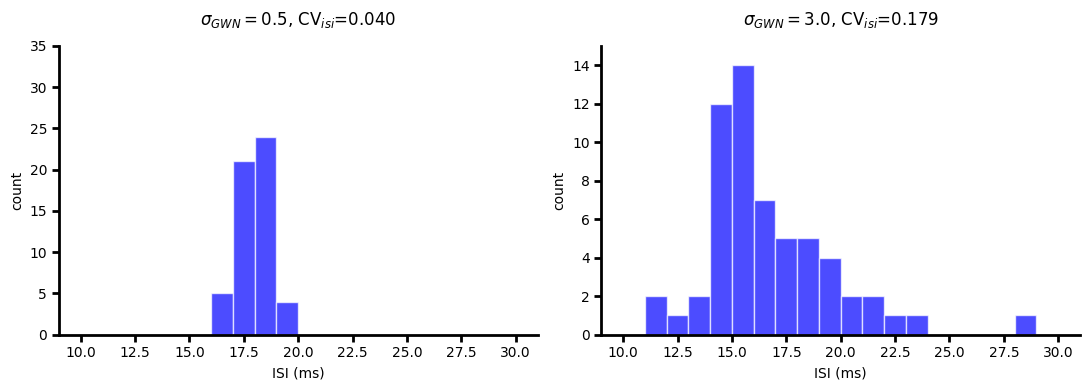

In [4]:
# --- 1. 你要填的 isi_cv_LIF 解答 ---
def isi_cv_LIF(spike_times):
    if len(spike_times) >= 2:
        isi = np.diff(spike_times)
        cv = np.std(isi) / np.mean(isi)
    else:
        isi = np.array([])
        cv = np.nan
    return isi, cv

# --- 2. 嚴格對齊 NMA 參數的 Brian2 模擬 ---
start_scope()

# 物理參數
tau_m = 10 * ms
E_L = -75 * mV
V_th = -55 * mV
V_reset = -75 * mV
g_L = 10 * nS
I_mu = 250 * pA
t_ref = 2 * ms
T_sim = 1000 * ms  # 嚴格設定為 1000 ms (NMA 預設值)

# 固定隨機種子
seed(2026) 

eqs = '''
dv/dt = (-(v - E_L) + I_mu/g_L) / tau_m + sigma * xi * tau_m**-0.5 : volt (unless refractory)
sigma : volt
'''

# 建立 2 個神經元
G = NeuronGroup(2, 
                model=eqs, 
                threshold='v > V_th', 
                reset='v = V_reset', 
                refractory=t_ref, 
                method='euler')
G.v = E_L
G.sigma = [0.5, 3.0] * mV  

spike_mon = SpikeMonitor(G)
run(T_sim)

# 提取數據
trains = spike_mon.spike_trains()
isi1, cv1 = isi_cv_LIF(trains[0] / ms)
isi2, cv2 = isi_cv_LIF(trains[1] / ms)

# isi1: 表示 spike 時間差 list

# --- 3. 完美模仿 NMA my_hists 的繪圖風格 ---
plt.figure(figsize=(11, 4))

# 強制對齊 NMA 的箱子切法：從 10 到 31，每 1 ms 一格
my_bins = np.arange(10, 32, 1) 

# --- 左圖：低噪音 ---
ax1 = plt.subplot(1, 2, 1)
ax1.hist(isi1, bins=my_bins, color='blue', alpha=0.7, edgecolor='white')
ax1.set_xlim(9, 31)
ax1.set_ylim(0, 35)
ax1.set_xlabel('ISI (ms)')
ax1.set_ylabel('count')
ax1.set_title(rf'$\sigma_{{GWN}} = 0.5$, CV$_{{isi}}$={cv1:.3f}', pad=15)
# 模仿 NMA 的邊框風格
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)
ax1.tick_params(width=2, length=5)

# --- 右圖：高噪音 ---
ax2 = plt.subplot(1, 2, 2)
ax2.hist(isi2, bins=my_bins, color='blue', alpha=0.7, edgecolor='white')
ax2.set_xlim(9, 31)
ax2.set_ylim(0, 15)
ax2.set_xlabel('ISI (ms)')
ax2.set_ylabel('count')
ax2.set_title(rf'$\sigma_{{GWN}} = 3.0$, CV$_{{isi}}$={cv2:.3f}', pad=15)
# 模仿 NMA 的邊框風格
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(2)
ax2.spines['bottom'].set_linewidth(2)
ax2.tick_params(width=2, length=5)

plt.tight_layout()
plt.show()

In [5]:
@widgets.interact(
    tau_m_val=widgets.FloatSlider(value=10.0, min=2.0, max=50.0, step=1.0, description='tau_m (ms)'),
    sigma_val=widgets.FloatSlider(value=2.0, min=0.0, max=10.0, step=0.5, description='Noise σ (mV)'),
    V_th_val=widgets.FloatSlider(value=-55.0, min=-70.0, max=-40.0, step=1.0, description='V_th (mV)'),
    t_ref_val=widgets.FloatSlider(value=5.0, min=0.0, max=20.0, step=1.0, description='t_ref (ms)')
)
def plot_interactive_FI_CV(tau_m_val=10.0, sigma_val=2.0, V_th_val=-55.0, t_ref_val=5.0):
    # 1. 隔離作用域 (非常重要！確保每次拉動滑桿不會被上一次的變數干擾)
    start_scope()
    
    # 2. 物理參數設定
    N = 50                 # 模擬 50 個接收不同電流的神經元
    tau_m = tau_m_val * ms 
    E_L = -75 * mV
    V_th = V_th_val * mV
    V_reset = -80 * mV 
    g_L = 10 * nS
    sigma = sigma_val * mV  
    t_ref = t_ref_val * ms  
    
    # 為了讓滑桿反應快一點，這裡把模擬時間設為 1000 ms (1秒)
    T_total = 1000 * ms 
    
    # 3. 定義微分方程 (加入 I_inj 作為各個神經元的專屬變數)
    eqs = '''
    dv/dt = (-(v - E_L) + I_inj/g_L) / tau_m + sigma * xi * tau_m**-0.5 : volt (unless refractory)
    I_inj : amp 
    '''

    # 4. 建立神經元群體
    G = NeuronGroup(N, 
                    model=eqs, 
                    threshold='v > V_th', 
                    reset='v = V_reset', 
                    refractory=t_ref, 
                    method='euler')
    
    G.v = E_L
    
    # 給予 50 個神經元從 0 到 500 pA 等比例遞增的電流
    I_values = np.linspace(0, 500, N) * pA
    G.I_inj = I_values
    
    # 5. 監測器 (我們只需要知道什麼時候發射，不需要看電位變化了)
    spike_mon = SpikeMonitor(G)
    
    # 6. 執行模擬
    run(T_total)
    
    # 7. 數據後處理：計算 Firing Rate 與 CV_ISI
    rates = np.zeros(N)
    cv_isis = np.zeros(N)
    trains = spike_mon.spike_trains()
    
    for i in range(N):
        spike_times = trains[i] / ms
        
        # 頻率 = 放電次數 / 總時間(秒)
        rates[i] = len(spike_times) / (T_total / second)
        
        # 計算 ISI 與 CV (至少需要 3 個 Spike 才有意義)
        if len(spike_times) >= 3:
            isi = np.diff(spike_times)
            cv_isis[i] = np.std(isi) / np.mean(isi)
        else:
            cv_isis[i] = np.nan
            
    # 8. 繪圖
    plt.figure(figsize=(14, 5))
    
    # 圖 A: F-I 曲線
    plt.subplot(1, 2, 1)
    plt.plot(I_values/pA, rates, marker='o', markersize=4, color='tab:blue', alpha=0.8)
    plt.title(f'F-I Curve (Frequency vs Current)\nσ={sigma_val}mV, τ_m={tau_m_val}ms')
    plt.xlabel('Input Current $I_{inj}$ (pA)')
    plt.ylabel('Firing Rate (Hz)')
    plt.ylim(-5, 120)  # 固定 y 軸高度，方便觀察曲線變化
    plt.grid(True, alpha=0.3)
    
    # 圖 B: CV_ISI 曲線
    plt.subplot(1, 2, 2)
    plt.plot(I_values/pA, cv_isis, marker='o', markersize=4, color='tab:orange', alpha=0.8)
    plt.title(f'$CV_{{ISI}}$ (Irregularity vs Current)\nRefractory={t_ref_val}ms')
    plt.xlabel('Input Current $I_{inj}$ (pA)')
    plt.ylabel('$CV_{ISI}$')
    plt.ylim(-0.1, 1.5) # 固定 y 軸高度
    plt.axhline(1.0, color='gray', linestyle=':', label='Poisson (CV=1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=10.0, description='tau_m (ms)', max=50.0, min=2.0, step=1.0), FloatSli…